# ProfNER: Detecting Profession Mentions in Tweets

Binary classification task: does a tweet mention a healthcare profession? Built on
the [ProfNER](https://temu.bsc.es/smm4h-spanish) shared task, using tweets from the
COVID-19 pandemic ([dataset on Hugging Face](https://huggingface.co/datasets/luisgasco/profner_classification_master)).

This notebook covers the exploratory analysis. Model training lives in `src/` --
`src/baseline.py` (TF-IDF + Logistic Regression, runs in seconds on CPU) and
`src/train.py` (BERTIN RoBERTa fine-tuning, needs a GPU). See the README for the
full results comparison and a discussion of whether the transformer's cost is
justified here.

## Load data

In [1]:
import sys
from pathlib import Path

# Make the `src` package importable when this notebook runs from notebooks/
if Path.cwd().name == "notebooks":
    sys.path.insert(0, str(Path.cwd().parent))

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from datasets import load_dataset

from src.preprocess import DATASET_NAME, clean_text

dataset = load_dataset(DATASET_NAME)
train_df = dataset["train"].to_pandas()
val_df = dataset["validation"].to_pandas()
test_df = dataset["test"].to_pandas()

print(f"Train: {len(train_df)}  Validation: {len(val_df)}  Test: {len(test_df)}")

C:\Users\Usuario\.pyenv\pyenv-win\versions\3.11.9\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Train: 2786  Validation: 999  Test: 1001


## Class balance and data quality

In [2]:
print("Duplicates -- train:", train_df.duplicated().sum(),
      "val:", val_df.duplicated().sum(), "test:", test_df.duplicated().sum())
print("\nMissing values (train):")
print(train_df.isna().sum())

print("\nTrain label counts:")
print(train_df["label"].value_counts())
print("\nValidation label counts:")
print(val_df["label"].value_counts())

Duplicates -- train: 0 val: 0 test: 0

Missing values (train):
tweet_id    0
text        0
label       0
dtype: int64

Train label counts:
label
1    1393
0    1393
Name: count, dtype: int64

Validation label counts:
label
0    761
1    238
Name: count, dtype: int64


Train is artificially balanced (1,393 positive / 1,393 negative). Validation keeps
the natural class distribution instead: 238 positive / 761 negative, roughly 24%
positive. That mismatch matters -- production traffic will look like validation
(and test), not train, which is exactly why both the baseline and BERTIN are
trained with class weighting rather than assuming a 50/50 split at inference.

## Tweet length by class

C:\Users\Usuario\AppData\Local\Temp\ipykernel_22512\3025974100.py:5: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator. Otherwise, ticks may be mislabeled.
  ax.set_xticklabels(["No profession (0)", "Mentions profession (1)"])


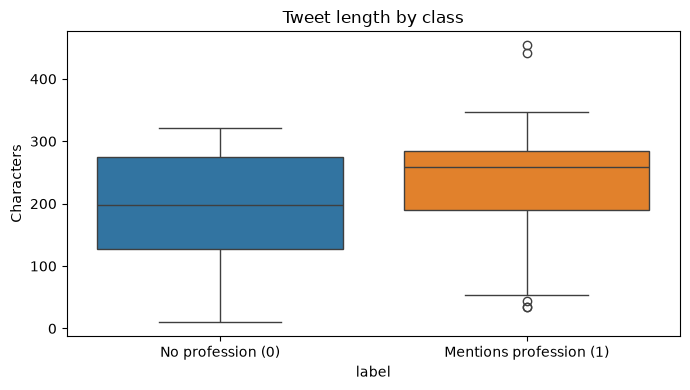

,count,mean,std,min,25%,50%,75%,max
label,,,,,,,,
0,1393.0,193.451543,82.383229,10.0,127.0,198.0,274.0,321.0
1,1393.0,236.663317,64.759120,34.0,190.0,259.0,285.0,454.0


In [3]:
train_df["char_length"] = train_df["text"].apply(len)

fig, ax = plt.subplots(figsize=(7, 4))
sns.boxplot(data=train_df, x="label", y="char_length", hue="label", ax=ax, legend=False)
ax.set_xticklabels(["No profession (0)", "Mentions profession (1)"])
ax.set_ylabel("Characters")
ax.set_title("Tweet length by class")
plt.tight_layout()
plt.show()

train_df.groupby("label")["char_length"].describe()

Tweets mentioning a profession run noticeably longer (mean ~237 characters, median
~259) than tweets that don't (mean ~193, median ~198). Users appear to add more
context when naming a profession -- worth remembering if this model is ever
retrained with length-based features added deliberately, rather than left for the
transformer to discover implicitly.

## Text cleaning

In [4]:
sample = train_df["text"].iloc[0]
print("Before:", sample)
print("After: ", clean_text(sample))

for df in (train_df, val_df, test_df):
    df["text"] = df["text"].apply(clean_text)

Before: Las / os sanitarias / os no necesitan capas de superhéroes y superheroínas , necesitan fondos suficientes para los EPI que deben usar , para respiradores ... Exijámoslo 🧑 🏻‍ ⚕ ️ 👩 🏻‍ ⚕ ️ 👨 🏻‍ ⚕ ️ # MFyC # COVID19 # DespuésDeAplaudir https://t.co/lizZEYp5Jj
After:  las os sanitarias os no necesitan capas de superhéroes y superheroínas necesitan fondos suficientes para los epi que deben usar para respiradores exijámoslo mfyc covid despuésdeaplaudir


`clean_text` (in `src/preprocess.py`) lowercases, strips URLs and @mentions, drops
the `#` symbol while keeping the hashtag word, and removes anything that isn't a
Spanish letter or whitespace.

## Baseline: TF-IDF + Logistic Regression

In [5]:
from src.baseline import main as run_baseline

baseline_report = run_baseline()

TF-IDF + Logistic Regression  (threshold=0.51)
  F1:       0.5471
  Accuracy: 0.7017
  Confusion matrix: [[521, 240], [58, 180]]


## BERTIN: fine-tuned transformer

BERTIN RoBERTa (`bertin-project/bertin-roberta-base-spanish`) was fine-tuned for 4
epochs via `src/train.py`. That needs a GPU (roughly 15 minutes on a free Colab
T4) and isn't re-run inside this notebook. Its validation results, from the
training run this repo is based on:

| Metric | Value |
|---|---|
| F1 (threshold 0.42, tuned on validation) | 0.878 |
| Accuracy | 0.942 |

See the README for the full comparison against the baseline above, and for the
decision-threshold bug this repo fixes (the original notebook tuned a threshold
and then never applied it to the final predictions).

## Conclusion

The TF-IDF baseline lands at F1 ~ 0.55, well below BERTIN's F1 ~ 0.88 -- a 33-point
gap. For this task, the transformer's training cost is justified: language
pretrained specifically on Spanish appears to capture how profession mentions are
phrased in ways a bag-of-words model can't.

See `src/predict.py` for generating final test predictions with the (bug-fixed)
tuned threshold, and `app.py` for a live demo.